# GridSearch over `QuantileReg` on California housing

Tune two LightGBM hyperparameters using bracketlearn's own time-aware
CV inside each grid point (sklearn's `GridSearchCV` would silently
destroy time ordering for sequential data).

Then a **leaderboard** of competing model families benchmarked
against the grid winner — so we can see whether tuning `QuantileReg`
beats untuned alternatives.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import RidgeCV

warnings.filterwarnings(
    "ignore", message="X does not have valid feature names.*",
    category=UserWarning,
)

from bracketlearn.baselines import EmpiricalDistribution
from bracketlearn.composite import LiftedForecaster
from bracketlearn.lift import GlobalResidual
from bracketlearn.pipeline import ForecastPipeline
from bracketlearn.search import GridSearch
from bracketlearn.trainers import (
    MixtureNormals,
    NGBoostNormal,
    QuantileForest,
    QuantileReg,
    SklearnPoint,
)

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## Data + baseline

In [2]:
data = fetch_california_housing()
X = np.asarray(data.data, dtype=float)
y = np.asarray(data.target, dtype=float)
rng = np.random.default_rng(0)
keep = rng.choice(X.shape[0], size=3000, replace=False)
X, y = X[keep], y[keep]
ids = np.arange(X.shape[0])
ts = ids.astype(float)
print(f"X shape {X.shape}, y range ${y.min()*100:.0f}k–${y.max()*100:.0f}k")

X shape (3000, 8), y range $18k–$500k


Fit the marginal-y baseline once outside the grid. Every grid result
is reported as skill score against this anchor.

In [3]:
base_pipeline = ForecastPipeline(
    steps=[("emp", EmpiricalDistribution())],
    cv="kfold", n_folds=4, shuffle=True, random_state=0,
    refit_on_full=False,
)
base_result = base_pipeline.fit_predict(X, y, ids=ids, timestamps=ts)
baseline_crps = base_result.score(y, metrics=["crps"])["emp"]["crps"]
print(f"baseline Empirical CRPS = {baseline_crps:.4f}")

baseline Empirical CRPS = 0.6107


## Grid: 3 × 3 over (n_estimators, learning_rate)

In [4]:
prototype = ForecastPipeline(
    steps=[("qreg", QuantileReg(random_seed=0))],
    cv="kfold", n_folds=4, shuffle=True, random_state=0,
    refit_on_full=True,
)
n_est_grid = [50, 150, 400]
lr_grid = [0.03, 0.1, 0.2]
grid = {
    "qreg__n_estimators": n_est_grid,
    "qreg__learning_rate": lr_grid,
}
print(f"running GridSearch over {len(n_est_grid) * len(lr_grid)} points …")
search = GridSearch(
    prototype, param_grid=grid,
    scoring="crps", refit_stage="qreg",
)
search.fit(X, y, ids=ids, timestamps=ts)
print(f"best: {search.best_params_}  CRPS={search.best_score_:.4f}")
print(f"baseline CRPS={baseline_crps:.4f}  "
      f"best CRPSS={1-search.best_score_/baseline_crps:+.3f}")

running GridSearch over 9 points …


best: {'qreg__n_estimators': 400, 'qreg__learning_rate': 0.1}  CRPS=0.2501
baseline CRPS=0.6107  best CRPSS=+0.590


## Heatmap of the grid landscape

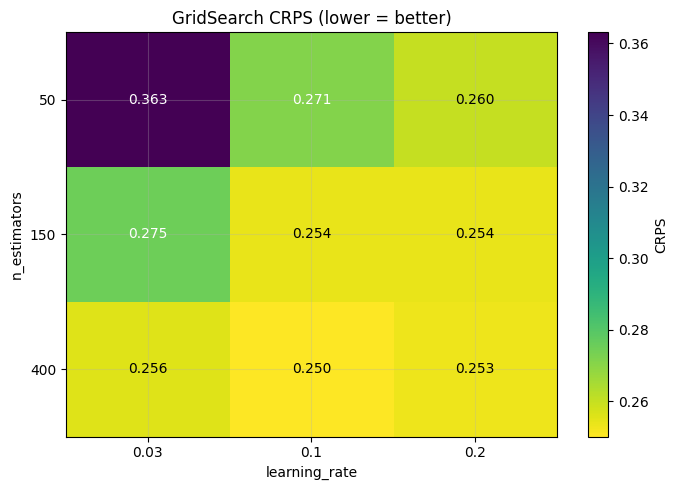

In [5]:
crps_matrix = np.full((len(n_est_grid), len(lr_grid)), np.nan)
for row in search.results_:
    n_est = row["params"]["qreg__n_estimators"]
    lr = row["params"]["qreg__learning_rate"]
    i = n_est_grid.index(n_est)
    j = lr_grid.index(lr)
    crps_matrix[i, j] = row["crps"]

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(crps_matrix, cmap="viridis_r", aspect="auto")
for i in range(len(n_est_grid)):
    for j in range(len(lr_grid)):
        ax.text(j, i, f"{crps_matrix[i,j]:.3f}",
                ha="center", va="center",
                color="white" if crps_matrix[i,j] > crps_matrix.mean() else "black")
ax.set_xticks(range(len(lr_grid)), labels=[str(lr) for lr in lr_grid])
ax.set_yticks(range(len(n_est_grid)), labels=[str(n) for n in n_est_grid])
ax.set_xlabel("learning_rate")
ax.set_ylabel("n_estimators")
ax.set_title("GridSearch CRPS (lower = better)")
plt.colorbar(im, label="CRPS")
plt.tight_layout(); plt.show()

Same data as skill bars — easier to spot the winner.

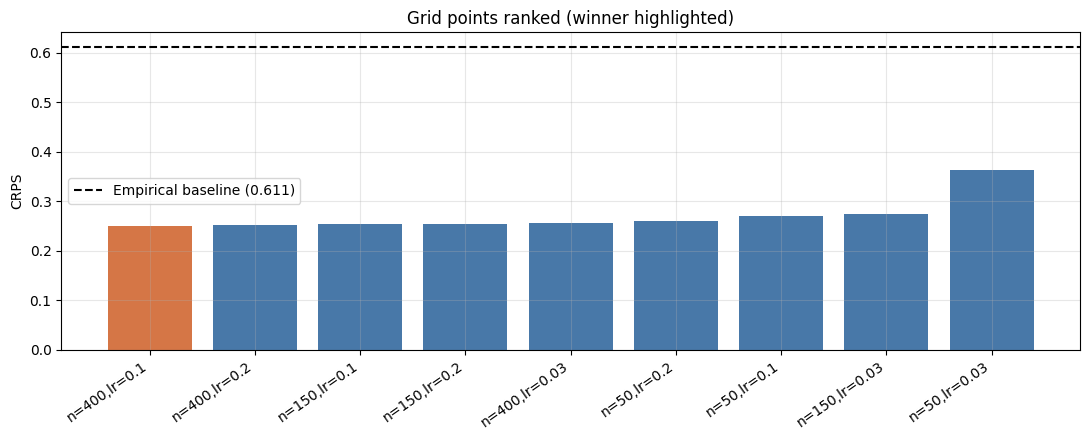

In [6]:
labels = [f"n={r['params']['qreg__n_estimators']},lr={r['params']['qreg__learning_rate']}"
          for r in search.results_]
crps_vals = [r["crps"] for r in search.results_]
order = np.argsort(crps_vals)
fig, ax = plt.subplots(figsize=(11, 4.5))
xs = np.arange(len(labels))
colors = ["#d57646" if i == order[0] else "#4878a8" for i in range(len(labels))]
ax.bar(xs, [crps_vals[i] for i in order], color=[colors[i] for i in order])
ax.axhline(baseline_crps, color="black", linestyle="--",
           label=f"Empirical baseline ({baseline_crps:.3f})")
ax.set_xticks(xs)
ax.set_xticklabels([labels[i] for i in order], rotation=35, ha="right")
ax.set_ylabel("CRPS")
ax.set_title("Grid points ranked (winner highlighted)")
ax.legend()
plt.tight_layout(); plt.show()

## Predicted quantile fan from the best pipeline

`best_pipeline_` is already refit on the full training data. Predict
on a held-out slice and plot 10/50/90 % bands against realised price.

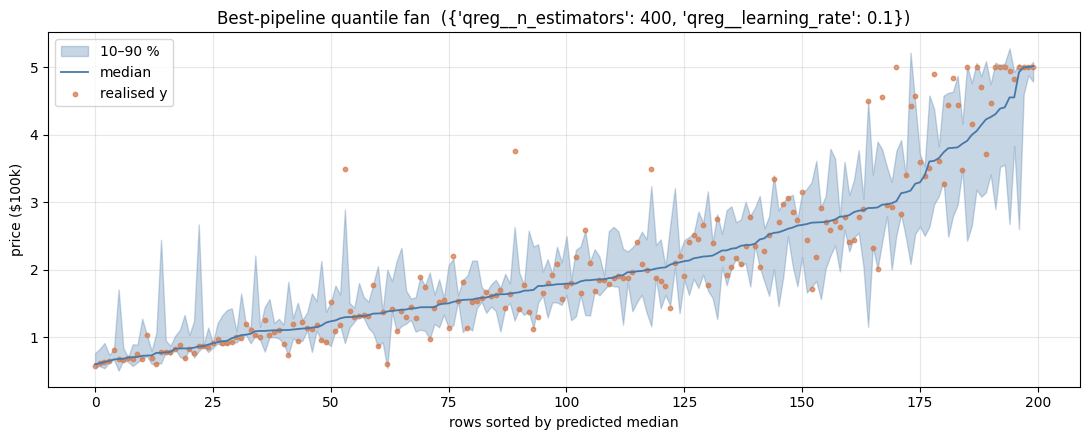

In [7]:
test_idx = rng.choice(X.shape[0], size=200, replace=False)
pred = search.best_pipeline_.predict(
    X[test_idx], ids=np.arange(test_idx.size),
    timestamps=np.arange(test_idx.size, dtype=float),
)["qreg"]

taus = pred.taus
i_lo, i_md, i_hi = (np.argmin(np.abs(taus - q)) for q in (0.1, 0.5, 0.9))
order = np.argsort(pred.qvals[:, i_md])
xs = np.arange(order.size)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.fill_between(xs, pred.qvals[order, i_lo], pred.qvals[order, i_hi],
                alpha=0.3, color="#4878a8", label="10–90 %")
ax.plot(xs, pred.qvals[order, i_md], color="#4878a8", lw=1.3,
        label="median")
ax.scatter(xs, y[test_idx][order], s=10, color="#d57646", alpha=0.7,
           label="realised y")
ax.set_xlabel("rows sorted by predicted median")
ax.set_ylabel("price ($100k)")
ax.set_title(f"Best-pipeline quantile fan  "
             f"({search.best_params_})")
ax.legend(loc="upper left")
plt.tight_layout(); plt.show()

## Leaderboard: competing model families

Is tuned `QuantileReg` actually the best, or would an untuned ensemble
do better? Five competing trainers; sort by CRPS.

rank model                       CRPS     CRPSS
-----------------------------------------------
1    QuantileReg (best)        0.2501    +0.590
2    QuantileForest            0.2840    +0.535
3    NGBoostNormal             0.3470    +0.432
4    Ridge+GR                  0.4155    +0.320
5    Empirical                 0.6107    +0.000
6    MixtureNormals           23.2715   -37.106


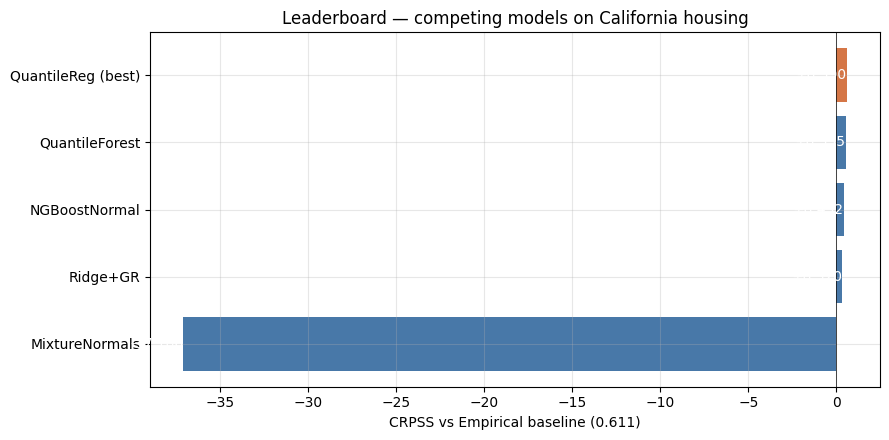

In [8]:
def _score_full(stage_name, forecaster):
    p = ForecastPipeline(
        steps=[(stage_name, forecaster)],
        cv="kfold", n_folds=4, shuffle=True, random_state=0,
        refit_on_full=False,
    )
    r = p.fit_predict(X, y, ids=ids, timestamps=ts)
    return r.score(y, metrics=["crps"])[stage_name]["crps"]


lb = {
    "Empirical":            baseline_crps,
    "Ridge+GR":             _score_full("ridge", LiftedForecaster(
        SklearnPoint(RidgeCV()), GlobalResidual(), name="ridge",
    )),
    "MixtureNormals":       _score_full("mix", MixtureNormals()),
    "NGBoostNormal":        _score_full("ngb", NGBoostNormal(
        n_estimators=200, random_seed=0,
    )),
    "QuantileForest":       _score_full("qf", QuantileForest(
        n_estimators=200, random_seed=0,
    )),
    "QuantileReg (best)":   search.best_score_,
}

rows = sorted(lb.items(), key=lambda kv: kv[1])
print(f"{'rank':<5}{'model':<22}{'CRPS':>10}{'CRPSS':>10}")
print("-" * 47)
for i, (name, c) in enumerate(rows, 1):
    print(f"{i:<5}{name:<22}{c:>10.4f}{1-c/baseline_crps:>+10.3f}")

fig, ax = plt.subplots(figsize=(9, 4.5))
names = [r[0] for r in rows if r[0] != "Empirical"]
skills = [1 - r[1] / baseline_crps for r in rows if r[0] != "Empirical"]
colors = ["#d57646" if "best" in n else "#4878a8" for n in names]
ax.barh(names, skills, color=colors)
ax.axvline(0, color="black", linewidth=0.5)
ax.invert_yaxis()
ax.set_xlabel(f"CRPSS vs Empirical baseline ({baseline_crps:.3f})")
ax.set_title("Leaderboard — competing models on California housing")
for i, s in enumerate(skills):
    ax.text(s - 0.003, i, f"{s:+.3f}", va="center", ha="right",
            color="white")
plt.tight_layout(); plt.show()

## Point-forecast benchmark — RMSE / MAE vs sklearn

Collapse `best_pipeline_`'s OOF distribution to its mean → RMSE/MAE
and compare against plain `RidgeCV` and `LGBMRegressor` trained with
the same k-fold split. Are the probabilistic models also competitive
on classical point-prediction metrics?

rank model                       RMSE       MAE
-----------------------------------------------
1    QReg-best (→mean)         0.5236    0.3552
2    QReg-best (→median)       0.5256    0.3510
3    LightGBM                  0.5311    0.3626
4    sklearn RidgeCV           1.5882    0.5572


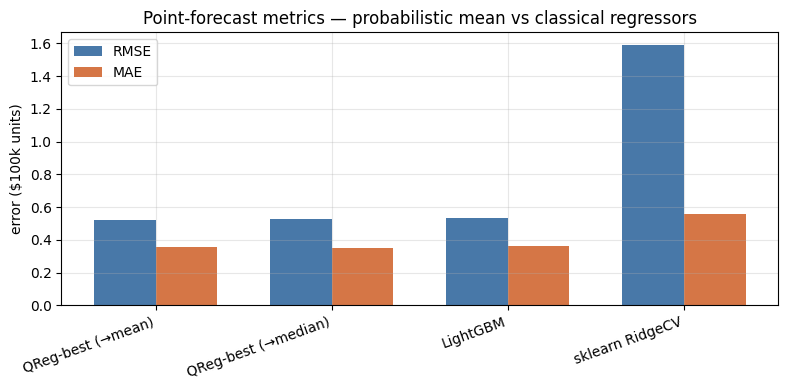

In [9]:
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import KFold

from bracketlearn.score import to_point

# Refit the best pipeline with refit_on_full=False to get clean OOF dists.
best_eval = ForecastPipeline(
    steps=[("qreg", QuantileReg(
        n_estimators=search.best_params_["qreg__n_estimators"],
        learning_rate=search.best_params_["qreg__learning_rate"],
        random_seed=0,
    ))],
    cv="kfold", n_folds=4, shuffle=True, random_state=0,
    refit_on_full=False,
).fit_predict(X, y, ids=ids, timestamps=ts)
dist = best_eval["qreg"]
y_oof = y[dist.ids.astype(int)]
mu_best = to_point(dist, how="mean")
mu_med = to_point(dist, how="median")


def _sklearn_oof(model_factory):
    kf = KFold(n_splits=4, shuffle=True, random_state=0)
    preds = np.empty_like(y)
    for tr, te in kf.split(X):
        m = model_factory()
        m.fit(X[tr], y[tr])
        preds[te] = m.predict(X[te])
    return preds


sk_ridge_pred = _sklearn_oof(lambda: RidgeCV())
sk_lgb_pred = _sklearn_oof(lambda: LGBMRegressor(
    n_estimators=200, learning_rate=0.05, verbose=-1, random_state=0,
))


def _metrics(name, pred, y_ref):
    return (name,
            float(np.sqrt(mean_squared_error(y_ref, pred))),
            float(mean_absolute_error(y_ref, pred)))


point_rows = [
    _metrics("QReg-best (→mean)",   mu_best, y_oof),
    _metrics("QReg-best (→median)", mu_med, y_oof),
    _metrics("sklearn RidgeCV",     sk_ridge_pred, y),
    _metrics("LightGBM",            sk_lgb_pred, y),
]
point_rows.sort(key=lambda r: r[1])

print(f"{'rank':<5}{'model':<22}{'RMSE':>10}{'MAE':>10}")
print("-" * 47)
for i, (n, r, a) in enumerate(point_rows, 1):
    print(f"{i:<5}{n:<22}{r:>10.4f}{a:>10.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
xs = np.arange(len(point_rows))
w = 0.35
ax.bar(xs - w/2, [r[1] for r in point_rows], w, color="#4878a8", label="RMSE")
ax.bar(xs + w/2, [r[2] for r in point_rows], w, color="#d57646", label="MAE")
ax.set_xticks(xs); ax.set_xticklabels([r[0] for r in point_rows],
                                       rotation=20, ha="right")
ax.set_ylabel("error ($100k units)")
ax.set_title("Point-forecast metrics — probabilistic mean vs classical regressors")
ax.legend()
plt.tight_layout(); plt.show()